In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\its0r\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\its0r\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
df = pd.read_csv("D:/NLP-Projects/sentiment-analysis-imdb/data/raw/IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

In [6]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [8]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [13]:
df.sample(5)

,review,sentiment
32218,A truly scary film. Happening across curmudgeo...,1
15740,I was pleasantly surprised by how good the mov...,1
13703,"Having seen the uncut version, I thought this ...",1
13850,I have not seen this movie! At least not in it...,1
13768,What a despairing film. Dress actors in furry ...,0


### Basic EDA

In [14]:
df["sentiment"].value_counts()

sentiment
1    24884
0    24698
Name: count, dtype: int64

In [15]:
df["sentiment"].value_counts(normalize = True) * 100

sentiment
1    50.187568
0    49.812432
Name: proportion, dtype: float64

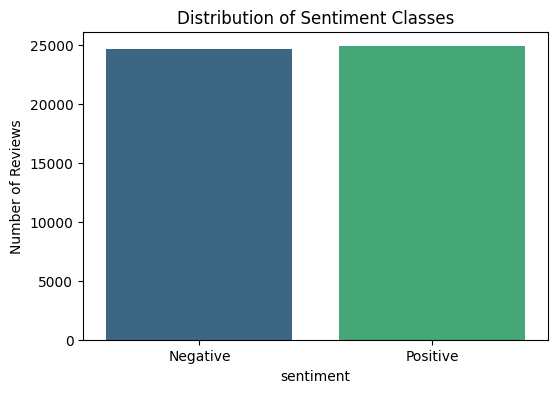

In [16]:
plt.figure(figsize =(6,4))

sns.countplot(
    data = df,
    x = "sentiment",
    hue = "sentiment",
    palette = "viridis",
    legend = False
)

plt.xticks([0,1], ["Negative","Positive"])
plt.xlabel("sentiment")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Sentiment Classes")

plt.show()

### Length Analysis

In [17]:
# Creating a column on number of characters in review
df["num_characters"] = df["review"].apply(len)

In [18]:
df[["review", "num_characters"]].head(3)

,review,num_characters
0,One of the other reviewers has mentioned that ...,1761
1,A wonderful little production. <br /><br />The...,998
2,I thought this was a wonderful way to spend ti...,926


In [19]:
# Creating a column on number of words in review
df["num_words"] = df["review"].apply(lambda x: len(x.split()))

In [21]:
from nltk.tokenize import sent_tokenize

# Creating a column on number of sentences in review
df["num_sentences"] = df["review"].apply(lambda x: len(sent_tokenize(x)))

In [22]:
df.head()

,review,sentiment,num_characters,num_words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,307,10
1,A wonderful little production. <br /><br />The...,1,998,162,7
2,I thought this was a wonderful way to spend ti...,1,926,166,4
3,Basically there's a family where a little boy ...,0,748,138,6
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230,9


In [23]:
df[["num_characters", "num_words", "num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,49582.000000,49582.000000,49582.000000
mean,1310.568230,231.350167,10.741519
std,990.762238,171.542020,7.817026
min,32.000000,4.000000,1.000000
25%,699.000000,126.000000,6.000000
50%,971.000000,173.000000,9.000000
75%,1592.000000,281.000000,13.000000
max,13704.000000,2470.000000,282.000000


In [24]:
df.groupby("sentiment")[["num_characters",
                         "num_words",
                         "num_sentences"]].mean().rename(
    index = {0: "Negative", 1: "Positive"}
)

,num_characters,num_words,num_sentences
sentiment,,,
Negative,1294.739615,229.596607,11.033484
Positive,1326.278532,233.090620,10.451736


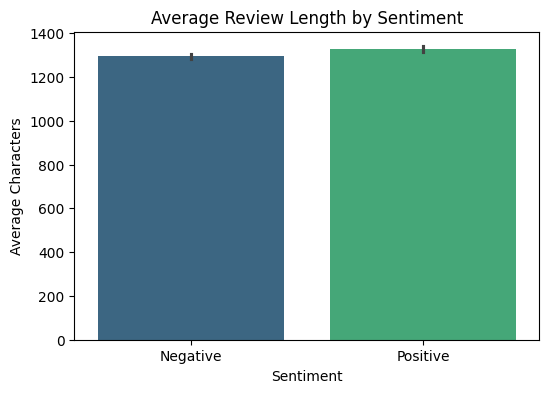

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="sentiment",
    y="num_characters",
    hue="sentiment",
    palette="viridis",
    legend=False
)

plt.xticks([0,1], ["Negative","Positive"])
plt.xlabel("Sentiment")
plt.ylabel("Average Characters")
plt.title("Average Review Length by Sentiment")

plt.show()

### Visulaizations

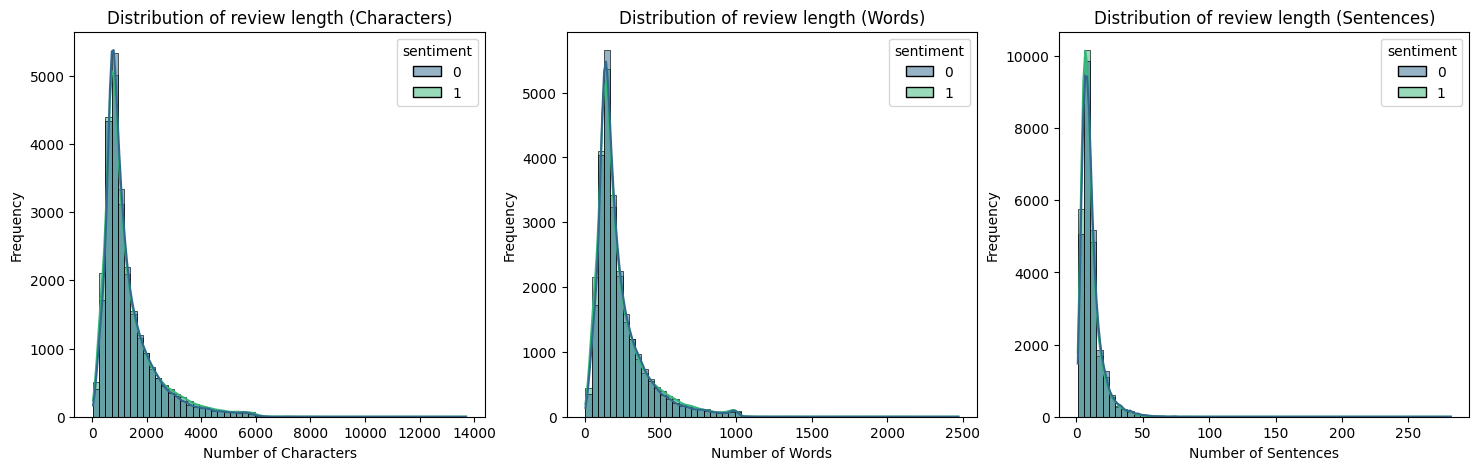

<Figure size 640x480 with 0 Axes>

In [26]:
# Making Histograms

fig, axes = plt.subplots(1,3, figsize = (18,5))

def make_histogram(data, x, hue, bins, ax, title):

    sns.histplot(
        data = data,
        x = x,
        hue = hue,
        bins = bins,
        kde= True,
        palette= "viridis",
        alpha=0.5,
        ax = axes[ax]
    )

    axes[ax].set_xlabel(f"Number of {title}")
    axes[ax].set_ylabel("Frequency")
    axes[ax].set_title(f"Distribution of review length ({title})")
    

make_histogram(df, "num_characters", "sentiment", 60, 0, "Characters")
make_histogram(df, "num_words", "sentiment", 60, 1, "Words")
make_histogram(df, "num_sentences", "sentiment", 60, 2, "Sentences")

plt.show()  
plt.tight_layout()

**Observation:**
The distributions of review length (characters, words, and sentences) are all heavily right-skewed, indicating that most reviews are of moderate length while a small number are exceptionally long. The positive and negative sentiment distributions almost completely overlap across all three features, suggesting that review length alone provides little information for distinguishing sentiment. Therefore, effective sentiment classification will depend on the textual content and semantic relationships between words rather than document length.

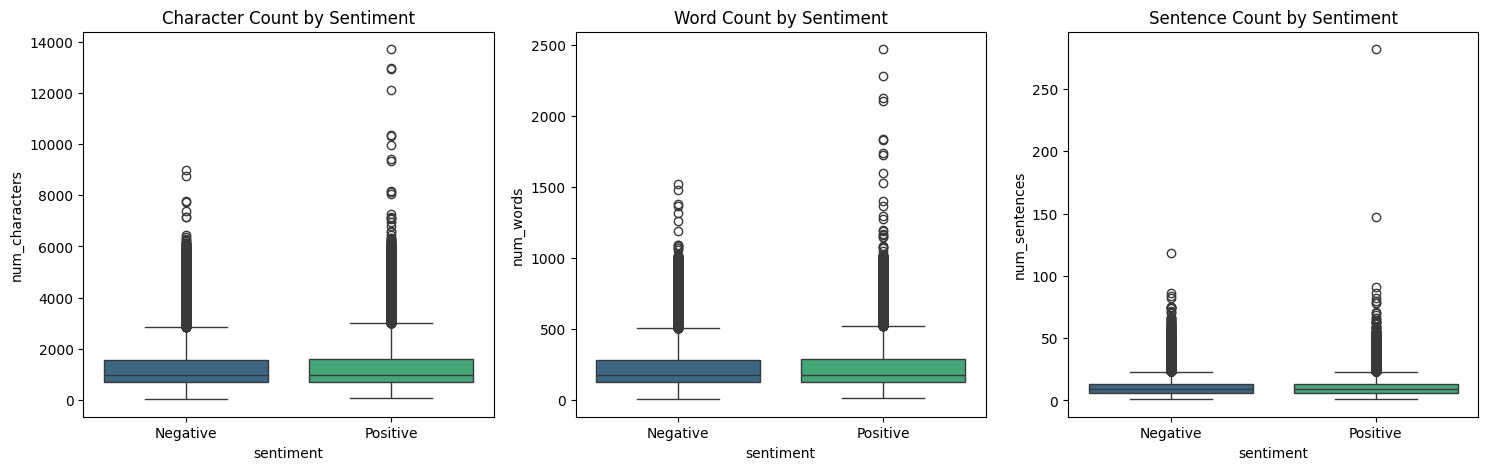

<Figure size 640x480 with 0 Axes>

In [27]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

def make_boxplot( data, y, ax, title):
    sns.boxplot(
        data =df,
        x="sentiment",
        y=y,
        hue="sentiment",
        palette="viridis",
        legend=False,
        ax = axes[ax]
    )

    axes[ax].set_xticks([0, 1])
    axes[ax].set_xticklabels(["Negative", "Positive"])
    axes[ax].set_title(f"{title} Count by Sentiment")


make_boxplot(df,"num_characters", 0, "Character")
make_boxplot(df,"num_words", 1, "Word")
make_boxplot(df,"num_sentences", 2, "Sentence")

plt.show()
plt.tight_layout()


**Observation:**
Both positive and negative reviews have very similar median lengths and spread. Although there are many extremely long reviews (shown as outliers), these are valid user-written reviews rather than errors, so they will be kept in the dataset. Overall, review length does not appear to be a strong indicator of sentiment.

In [28]:
corr = df[["num_characters",
           "num_words",
           "num_sentences"]].corr()

corr

,num_characters,num_words,num_sentences
num_characters,1.000000,0.996844,0.800240
num_words,0.996844,1.000000,0.812932
num_sentences,0.800240,0.812932,1.000000


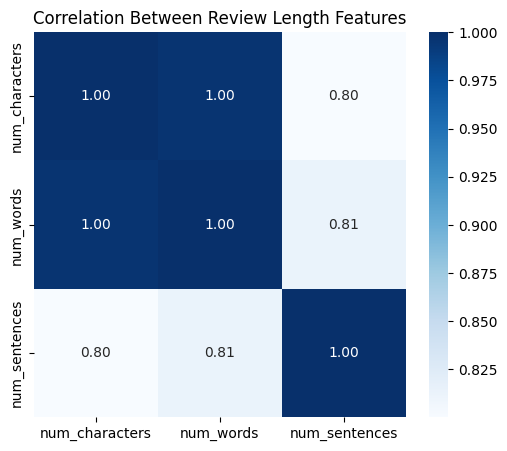

In [29]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Review Length Features")
plt.show()

**Observation:**
The heatmap shows a very strong positive correlation between the number of characters and the number of words, which is expected because longer reviews naturally contain more words. The number of sentences is also positively correlated with both features, although the relationship is slightly weaker due to variations in sentence length. Overall, these features capture similar aspects of review length.

### Preprocessing

In [30]:
# checking if the reviews contains html or not

df["review"].str.contains("<").sum()

np.int64(28976)

In [31]:
# checking if the reviews contains urls or not

df["review"].str.contains(r"http|www", regex = True).sum()

np.int64(234)

In [34]:
from bs4 import BeautifulSoup
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

stop_words = set(stopwords.words("english"))

# Preserve negation words because they are crucial for sentiment analysis.
# Example:
# "This movie is good."      -> Positive
# "This movie is not good."  -> Negative
negations = {
    "no",
    "not",
    "nor"
}
stop_words = stop_words - negations

lemmatizer = WordNetLemmatizer()

def transform_text(text, remove_stopwords=True, lemmatize=True):

    lower_text = text.lower()

    html_cleaned_text = BeautifulSoup(
        lower_text,
        "html.parser"
    ).get_text()

    url_cleaned_text = re.sub(
        r"http\S+|www\S+",
        "",
        html_cleaned_text
    )

    # convert don't to do not 
    expanded_text = contractions.fix(url_cleaned_text)

    # Separate punctuation that appears between two words like funny.the , good.Also
    expanded_text = re.sub(
        r"(?<=[A-Za-z])([.,!?;:])(?=[A-Za-z])",
        r" \1 ",
        expanded_text
    )
    
    tokens = word_tokenize(expanded_text)

    # Removing starting and trailing punctuations 'movie -> movie
    tokens = [
    token.strip(string.punctuation)
    for token in tokens
    ]

    # Keep only tokens containing at least one alphanumeric character (i.e. Remove standalone punctuation tokens
    tokens = [
        token
        for token in tokens
        if any(ch.isalnum() for ch in token)
    ]
    
    if remove_stopwords:
        
        tokens = [
            word
            for word in tokens
            if word and word not in stop_words
        ]

    if lemmatize:
        
        tokens = [
            lemmatizer.lemmatize(word)
            for word in tokens
        ]

    return " ".join(tokens)
    

In [35]:
s = "I wasn't interested .... in this 'movie'. www.google.com amazing!!! However didn't expect this movie to be this good.I would give(assign) it a 7/10 stars. Sometimes it becomes boring but it agian sets pace and gets better."

transform_text(s, True)

'not interested movie amazing however not expect movie good would give assign 7/10 star sometimes becomes boring agian set pace get better'

In [36]:
df["clean_review"] = df["review"].apply(
    lambda x: transform_text(
        x,
        remove_stopwords=True,
        lemmatize=True
    )
)

df["embedding_review"] = df["review"].apply(
    lambda x: transform_text(
        x,
        remove_stopwords=False,
        lemmatize=False
    )
)

In [37]:
df[["review", "clean_review", "embedding_review"]].sample(5)

,review,clean_review,embedding_review
19312,This film is based on the novel by John Fante....,film based novel john fante could someone plea...,this film is based on the novel by john fante ...
3842,I was impressed with this film because of the ...,impressed film quality acting powerful message...,i was impressed with this film because of the ...
3185,Again Stacy Peralta is true first to the peopl...,stacy peralta true first people lived story le...,again stacy peralta is true first to the peopl...
17063,I've read a lot of comments about the film and...,read lot comment film hard people believe sequ...,i have read a lot of comments about the film a...
46853,I wasn't at all a fan of the 2005 gore fest hi...,not fan 2005 gore fest hit hostel lame as knoc...,i was not at all a fan of the 2005 gore fest h...


In [38]:
df.loc[21427, "clean_review"]

'one awful movie misfortune picking not get wrong love good zombie flick not one might well opening scene least called titty zombie outer space absolutely nothing movie video game far could tell best aspect film two main character get covered much blood remain nonplussed would certainly suggest giving one miss staying safer zombie pleaser like 28 day later dawn living dead remake course unless serious campy action'

In [40]:
from wordcloud import WordCloud

def make_wordcloud(sentiment_num, sentiment_name, custom_stopwords):
    text = " ".join(
        df[df["sentiment"] == sentiment_num]["clean_review"]
    )

    wc = WordCloud(
        width =800,
        height =400,
        background_color="white",
        max_words=200,
        stopwords = custom_stopwords
    ).generate(text)

    plt.figure(figsize=(15, 8))
    plt.imshow(wc, interpolation = "bilinear")
    plt.axis("off")
    
    plt.title(f"Most Frequent Words in {sentiment_name} Reviews")

    plt.show()
    

In [43]:
custom_stopwords = { "movie", "film","character","scene","story","show","one",
                     "time","even","also","see","make","would","way","think"
                   }

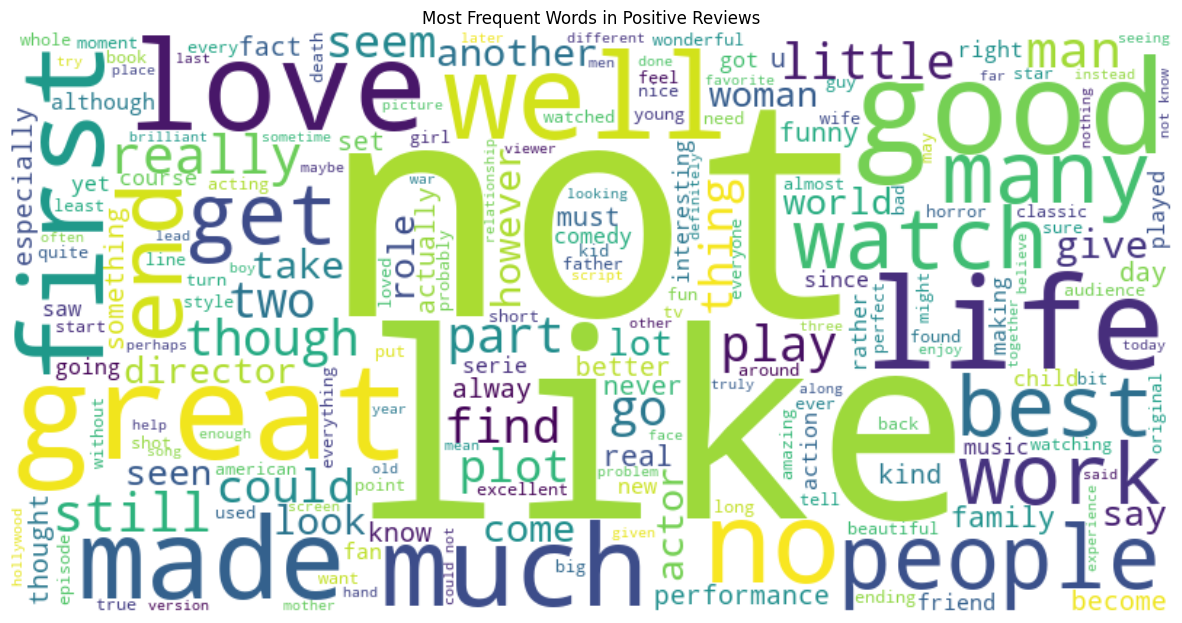

In [44]:
# Making positive word cloud with custom_stopwords
make_wordcloud(1, "Positive", custom_stopwords)

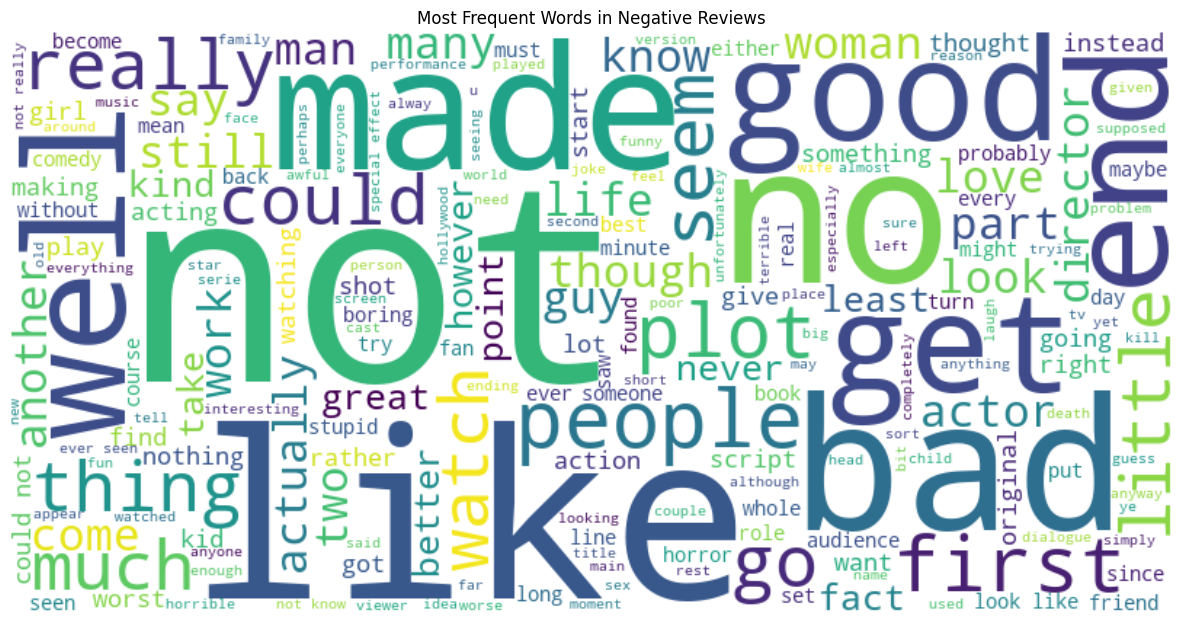

In [45]:
# Making negative word cloud with custom stopwords
make_wordcloud(0, "Negative", custom_stopwords)

**Observation:**
The word clouds provide a high-level overview of the vocabulary used in positive and negative movie reviews. Both classes are dominated by common movie-related terms such as like, good, character, story, and director, indicating that these words frequently appear regardless of sentiment. Although some sentiment-bearing words are visible, unigram-based word clouds are limited because they ignore context. For example, phrases such as "don't like" and "really like" are reduced to the common word "like", making it difficult to distinguish positive and negative opinions. Therefore, while word clouds are useful for an initial exploration of the corpus, they are insufficient for capturing sentiment accurately.

In [46]:
from collections import Counter
import matplotlib.pyplot as plt

def plot_top_words(sentiment_num, sentiment_name, n=20):

    # Combine all reviews of the selected sentiment
    text = " ".join(
        df[df["sentiment"] == sentiment_num]["clean_review"]
    )

    # Split into individual words
    words = text.split()

    # Count word frequencies
    word_counts = Counter(words)

    # Get the n most common words
    common_words = word_counts.most_common(n)

    # Separate words and counts
    labels = [word for word, _ in common_words]
    counts = [count for _, count in common_words]

    # Plot
    plt.figure(figsize=(12,6))
    plt.bar(labels, counts)

    plt.title(f"Top {n} Words in {sentiment_name} Reviews")
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

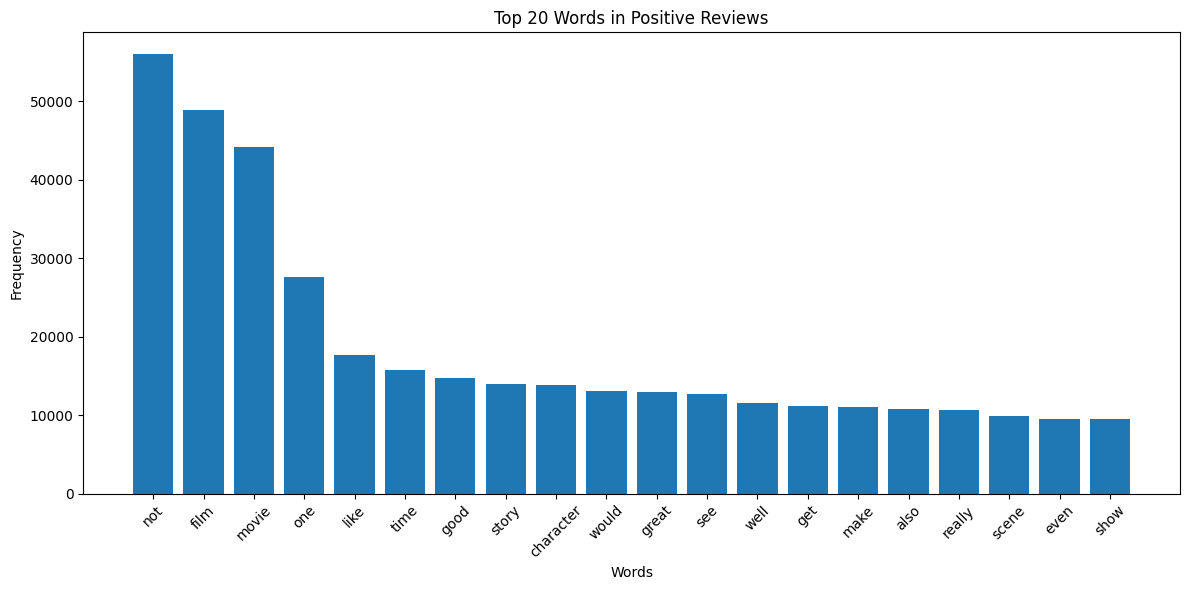

In [47]:
plot_top_words(1, "Positive")

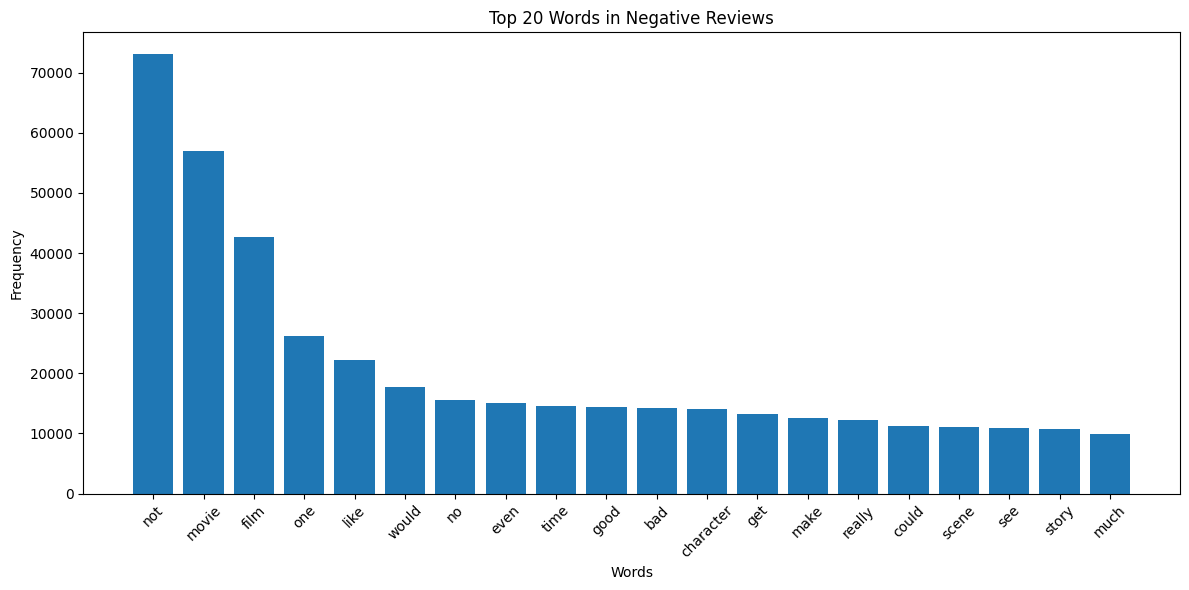

In [48]:
plot_top_words(0, "Negative")

In [49]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_bigrams(sentiment_num, sentiment_name, n=20):

    # Get all reviews of the selected sentiment
    text = df[df["sentiment"] == sentiment_num]["clean_review"]

    # Create a bigram vectorizer
    vectorizer = CountVectorizer(ngram_range=(2, 2))

    # Learn vocabulary and count bigrams
    X = vectorizer.fit_transform(text)

    # Sum frequencies across all documents
    frequencies = X.sum(axis=0).A1

    # Get bigram names
    bigrams = vectorizer.get_feature_names_out()

    # Create DataFrame
    bigram_df = pd.DataFrame({
        "Bigram": bigrams,
        "Frequency": frequencies
    })

    # Sort and select top n
    bigram_df = bigram_df.sort_values(
        by="Frequency",
        ascending=False
    ).head(n)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.barh(
        bigram_df["Bigram"],
        bigram_df["Frequency"]
    )

    plt.title(f"Top {n} Bigrams in {sentiment_name} Reviews")
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

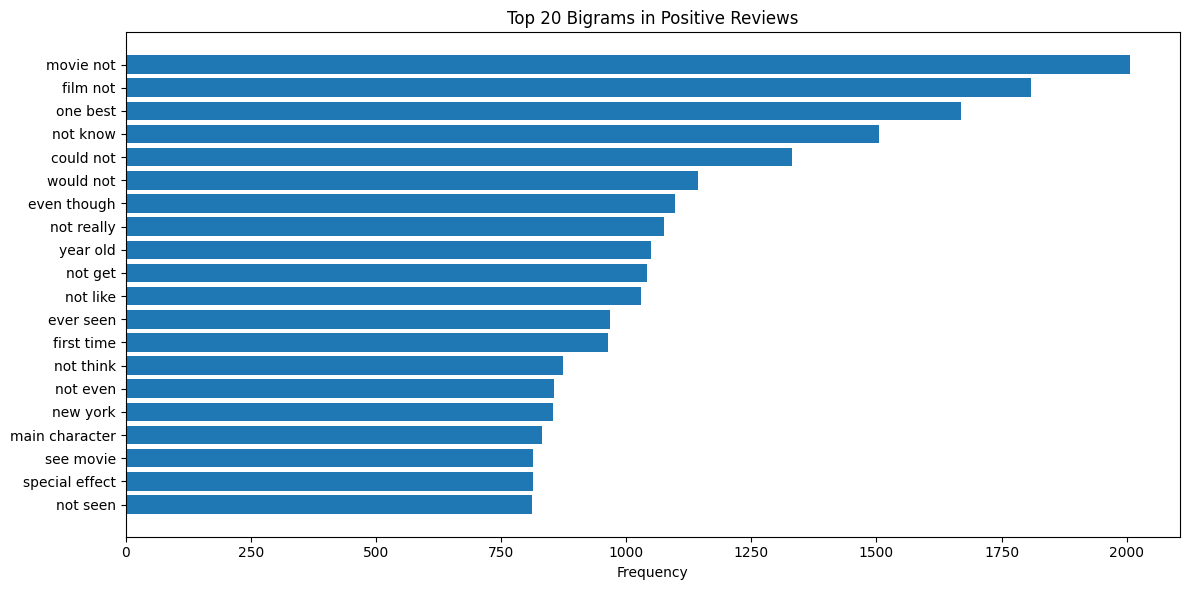

In [50]:
plot_top_bigrams(1, "Positive")

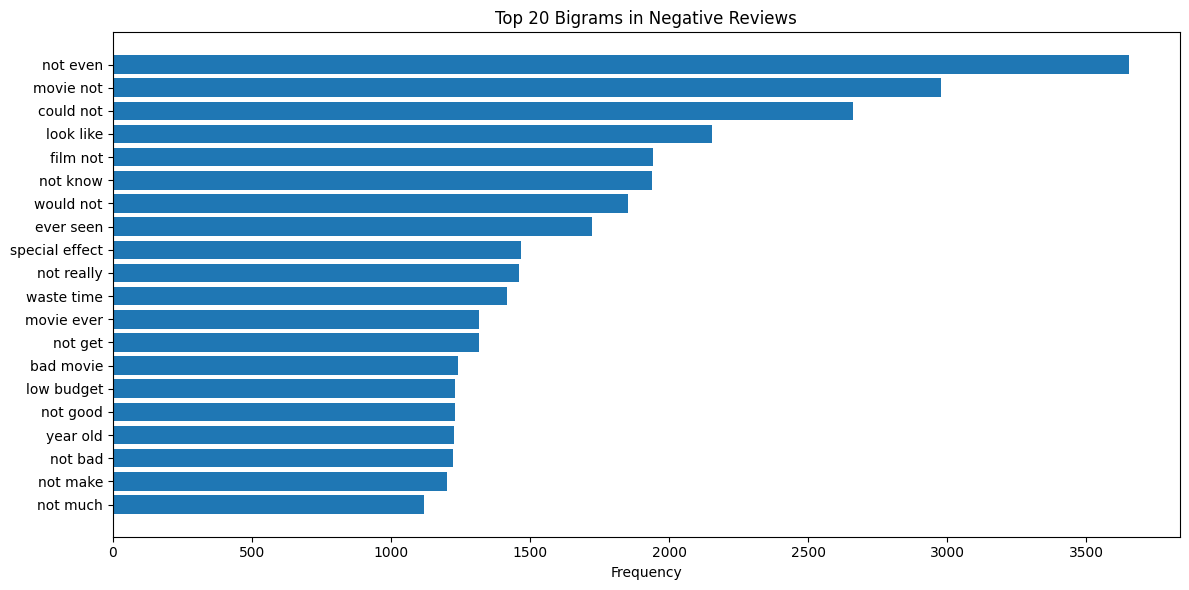

In [51]:
plot_top_bigrams(0, "Negative")

**Observation:** The textual analysis highlights that common movie-related words such as movie, film, and character dominate the corpus, regardless of sentiment. Preserving negation words (e.g., not, no) during preprocessing improves the interpretability of the results by retaining important sentiment cues. Bigram analysis provides more contextual information than individual words, revealing phrases such as not good, would not, and could not. However, frequency-based analyses remain limited because they cannot fully capture semantic meaning or long-range context. Therefore, more advanced text representation techniques are required for effective sentiment classification.

In [52]:
df.head(3)

,review,sentiment,num_characters,num_words,num_sentences,clean_review,embedding_review
0,One of the other reviewers has mentioned that ...,1,1761,307,10,one reviewer mentioned watching 1 oz episode h...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,1,998,162,7,wonderful little production filming technique ...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,1,926,166,4,thought wonderful way spend time hot summer we...,i thought this was a wonderful way to spend ti...


### Train Test split

In [57]:
from sklearn.model_selection import train_test_split

# First: split total data into train + validation set (80%) and test set (20%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["sentiment"]
)

# Second: split the remaining 80% into 72% train and 8% validation.
# 8% / 80% = 0.10
train_df, validation_df = train_test_split(
    train_val_df,
    test_size=0.10,
    random_state=42,
    stratify=train_val_df["sentiment"]
)

In [58]:
train_df.shape

(35698, 7)

In [59]:
validation_df.shape

(3967, 7)

In [60]:
test_df.shape

(9917, 7)

In [61]:
df.columns

Index(['review', 'sentiment', 'num_characters', 'num_words', 'num_sentences',
       'clean_review', 'embedding_review'],
      dtype='str')

### Saving the three csv files

In [62]:
train_df.to_csv(
    "D:/NLP-Projects/sentiment-analysis-imdb/data/processed/train.csv",
    index=False
)

validation_df.to_csv(
    "D:/NLP-Projects/sentiment-analysis-imdb/data/processed/validation.csv",
    index=False
)

test_df.to_csv(
    "D:/NLP-Projects/sentiment-analysis-imdb/data/processed/test.csv",
    index=False
)